In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!git clone https://github.com/gapDetection/gapDetectionDatasets.git \
    /kaggle/working/gapDetectionDatasets

Cloning into '/kaggle/working/gapDetectionDatasets'...
remote: Enumerating objects: 1301, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 1301 (delta 4), reused 0 (delta 0), pack-reused 1292 (from 1)
Receiving objects: 100% (1301/1301), 699.98 MiB | 29.44 MiB/s, done.
Resolving deltas: 100% (543/543), done.
Updating files: 100% (932/932), done.


In [2]:
!du -sh /kaggle/working/gapDetectionDatasets

1.5G	/kaggle/working/gapDetectionDatasets


In [3]:
!zip -r /kaggle/working/gapDetectionDatasets.zip \
    /kaggle/working/gapDetectionDatasets

  adding: kaggle/working/gapDetectionDatasets/ (stored 0%)
  adding: kaggle/working/gapDetectionDatasets/db251.jpg (deflated 34%)
  adding: kaggle/working/gapDetectionDatasets/README.md (deflated 57%)
  adding: kaggle/working/gapDetectionDatasets/001.jpg (deflated 29%)
  adding: kaggle/working/gapDetectionDatasets/.git/ (stored 0%)
  adding: kaggle/working/gapDetectionDatasets/.git/info/ (stored 0%)
  adding: kaggle/working/gapDetectionDatasets/.git/info/exclude (deflated 28%)
  adding: kaggle/working/gapDetectionDatasets/.git/packed-refs (deflated 9%)
  adding: kaggle/working/gapDetectionDatasets/.git/objects/ (stored 0%)
  adding: kaggle/working/gapDetectionDatasets/.git/objects/info/ (stored 0%)
  adding: kaggle/working/gapDetectionDatasets/.git/objects/pack/ (stored 0%)
  adding: kaggle/working/gapDetectionDatasets/.git/objects/pack/pack-ae2e6cb1ba62103a1d98cbb2698848a11be5bb77.pack (deflated 0%)
  adding: kaggle/working/gapDetectionDatasets/.git/objects/pack/pack-ae2e6cb1ba62103a1

In [1]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    for file in files:
        print("   ", os.path.join(root, file))

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/ramkiran23
/kaggle/input/datasets/ramkiran23/person-detection
    /kaggle/input/datasets/ramkiran23/person-detection/CONTRIBUTING.md
    /kaggle/input/datasets/ramkiran23/person-detection/LICENSE
    /kaggle/input/datasets/ramkiran23/person-detection/.gitignore
    /kaggle/input/datasets/ramkiran23/person-detection/README.md
    /kaggle/input/datasets/ramkiran23/person-detection/CODEOWNERS
    /kaggle/input/datasets/ramkiran23/person-detection/AUTHORS
    /kaggle/input/datasets/ramkiran23/person-detection/__init__.py
    /kaggle/input/datasets/ramkiran23/person-detection/setup.py
/kaggle/input/datasets/ramkiran23/person-detection/courses
/kaggle/input/datasets/ramkiran23/person-detection/courses/udacity_intro_to_tensorflow_lite
    /kaggle/input/datasets/ramkiran23/person-detection/courses/udacity_intro_to_tensorflow_lite/tflite_c02_transfer_learning.ipynb
    /kaggle/input/datasets/ramkiran23/person-detection/courses/udacity_

In [4]:
# Exact user-provided Kaggle paths. The notebook reads input data only from these locations.
from pathlib import Path

DATASET_ROOT = Path('/kaggle/input/datasets/aminefaris/retail-shelf-void-detection-dataset/void detection on retail shelves/')
TRAIN_IMAGES = Path('/kaggle/input/datasets/aminefaris/retail-shelf-void-detection-dataset/void detection on retail shelves/train/images/')
TRAIN_LABELS = Path('/kaggle/input/datasets/aminefaris/retail-shelf-void-detection-dataset/void detection on retail shelves/train/labels/')
TEST_IMAGES = Path('/kaggle/input/datasets/aminefaris/retail-shelf-void-detection-dataset/void detection on retail shelves/test/images/')
TEST_LABELS = DATASET_ROOT / 'test' / 'labels'  # inspected below; not assumed to exist
OUTPUT_ROOT = Path('/kaggle/working/retail_shelf_void_tf')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 320
GRID_SIZE = 10
VALIDATION_FRACTION = 0.15
BATCH_SIZE = 8
EPOCHS = 45
SEED = 42

for path in (DATASET_ROOT, TRAIN_IMAGES, TRAIN_LABELS, TEST_IMAGES):
    print(('OK     ' if path.exists() else 'MISSING'), path)

OK      /kaggle/input/datasets/aminefaris/retail-shelf-void-detection-dataset/void detection on retail shelves
OK      /kaggle/input/datasets/aminefaris/retail-shelf-void-detection-dataset/void detection on retail shelves/train/images
OK      /kaggle/input/datasets/aminefaris/retail-shelf-void-detection-dataset/void detection on retail shelves/train/labels
OK      /kaggle/input/datasets/aminefaris/retail-shelf-void-detection-dataset/void detection on retail shelves/test/images


In [5]:
# Inspect the dataset and label syntax before training. Nothing is modified or converted.
from collections import Counter

IMAGE_SUFFIXES = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
train_images = sorted(p for p in TRAIN_IMAGES.iterdir() if p.suffix.lower() in IMAGE_SUFFIXES)
label_files = sorted(TRAIN_LABELS.glob('*.txt'))
print('Train images:', len(train_images), '| Train labels:', len(label_files))
print('Root folders:', sorted(p.name for p in DATASET_ROOT.iterdir()))

sample = next((path for path in label_files if path.read_text().strip()), None)
if sample is None: raise ValueError('No non-empty YOLO label file was found.')
print('Sample label file:', sample.name)
print(sample.read_text()[:500])

classes = []
for label_path in label_files:
    for line in label_path.read_text().splitlines():
        values = line.split()
        if len(values) != 5:
            raise ValueError(f'Expected five YOLO values in {label_path}: {line!r}')
        class_id, *coords = values
        coords = [float(v) for v in coords]
        if int(float(class_id)) != 0 or not all(0.0 <= v <= 1.0 for v in coords):
            raise ValueError(f'Unexpected class/range in {label_path}: {line!r}')
        classes.append(int(float(class_id)))
print('YOLO class distribution:', Counter(classes))
assert train_images and classes, 'Data inspection failed. Check the exact Kaggle input paths.'

Train images: 506 | Train labels: 506
Root folders: ['data.yaml', 'test', 'train', 'valid']
Sample label file: IMG-20250318-WA0009_jpg.rf.3c7d769531baff15cf4672028a2fecfa.txt
0 0.4375 0.66328125 0.1046875 0.125
0 0.56796875 0.73828125 0.134375 0.1125
0 0.69296875 0.78984375 0.1328125 0.1359375
0 0.3328125 0.4421875 0.0578125 0.09375
0 0.1765625 0.08984375 0.2203125 0.1
YOLO class distribution: Counter({0: 2342})


In [6]:
# No pip install is required. TensorFlow is already provided by Kaggle.
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


In [7]:
# YOLO -> fixed grid target. Every grid cell predicts [objectness, local_cx, local_cy, width, height].
# A cell with multiple voids retains the larger one; this is a deliberate lightweight POC trade-off.
def target_for_image(image_path, label_dir):
    target = np.zeros((GRID_SIZE, GRID_SIZE, 5), dtype=np.float32)
    areas = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.float32)
    label_path = label_dir / f'{image_path.stem}.txt'
    if not label_path.exists():
        return target
    for line in label_path.read_text().splitlines():
        class_id, cx, cy, box_w, box_h = map(float, line.split())
        if int(class_id) != 0: continue
        gx = min(GRID_SIZE - 1, int(cx * GRID_SIZE))
        gy = min(GRID_SIZE - 1, int(cy * GRID_SIZE))
        area = box_w * box_h
        if area <= areas[gy, gx]: continue
        areas[gy, gx] = area
        target[gy, gx] = [1.0, cx * GRID_SIZE - gx, cy * GRID_SIZE - gy, box_w, box_h]
    return target

def make_arrays(images, labels):
    return np.asarray([str(path) for path in images]), np.stack([target_for_image(path, labels) for path in images])

rng = random.Random(SEED)
shuffled = train_images.copy(); rng.shuffle(shuffled)
split = max(1, int(len(shuffled) * VALIDATION_FRACTION))
val_images, fit_images = sorted(shuffled[:split]), sorted(shuffled[split:])
fit_paths, fit_targets = make_arrays(fit_images, TRAIN_LABELS)
val_paths, val_targets = make_arrays(val_images, TRAIN_LABELS)
print({'fit_images': len(fit_paths), 'validation_images': len(val_paths),
       'fit_void_cells': int(fit_targets[..., 0].sum()), 'validation_void_cells': int(val_targets[..., 0].sum())})

{'fit_images': 431, 'validation_images': 75, 'fit_void_cells': 1973, 'validation_void_cells': 334}


I0000 00:00:1788606366.132555      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788606366.138633      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


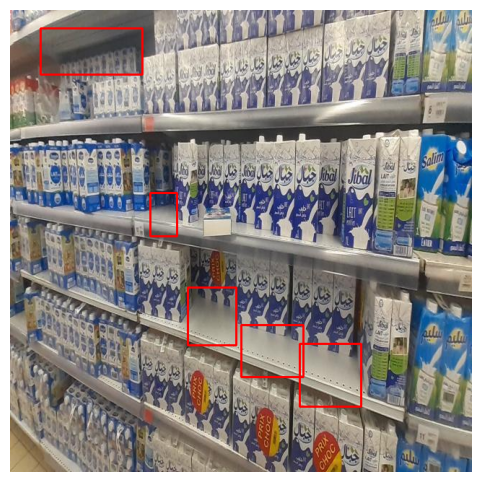

In [8]:
def load_example(path, target):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, target

def make_dataset(paths, targets, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, targets))
    if training:
        dataset = dataset.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    return dataset.map(load_example, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

fit_ds = make_dataset(fit_paths, fit_targets, training=True)
val_ds = make_dataset(val_paths, val_targets)

# View a correctly decoded target before training. Red = labelled void.
image = cv2.imread(fit_paths[0]); image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
h, w = image.shape[:2]
for gy, gx in zip(*np.where(fit_targets[0, ..., 0] == 1)):
    _, tx, ty, bw, bh = fit_targets[0, gy, gx]
    cx, cy = (gx + tx) * w / GRID_SIZE, (gy + ty) * h / GRID_SIZE
    x1, y1, x2, y2 = int((cx-bw*w/2)), int((cy-bh*h/2)), int((cx+bw*w/2)), int((cy+bh*h/2))
    cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
plt.figure(figsize=(10, 6)); plt.imshow(image); plt.axis('off'); plt.show()

In [11]:
# Compact pure-Keras detector. Its 10x10 output grid directly matches the target encoding above.
inputs = tf.keras.Input((IMAGE_SIZE, IMAGE_SIZE, 3), name='shelf_rgb')
x = inputs
for filters in (32, 64, 96, 160, 224):
    x = tf.keras.layers.SeparableConv2D(filters, 3, strides=2, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU(6.0)(x)
x = tf.keras.layers.Conv2D(160, 3, padding='same', activation='relu')(x)
outputs = tf.keras.layers.Conv2D(5, 1, padding='same', activation='sigmoid', name='void_grid')(x)
void_model = tf.keras.Model(inputs, outputs, name='shelf_void_grid_detector')
assert void_model.output_shape[1:] == (GRID_SIZE, GRID_SIZE, 5), void_model.output_shape

def void_grid_loss(y_true, y_pred):
    # Keep every loss/mask tensor at [batch, grid_y, grid_x].
    # This avoids the Keras 3 broadcasting error from a trailing singleton dimension.
    object_true = y_true[..., 0]
    object_pred = y_pred[..., 0]
    object_bce = tf.keras.backend.binary_crossentropy(object_true, object_pred)
    # Positive cells are much rarer than background cells.
    object_loss = tf.reduce_mean(object_bce * (1.0 + 8.0 * object_true))
    box_delta = tf.abs(y_true[..., 1:] - y_pred[..., 1:])
    box_huber = 0.5 * tf.square(tf.minimum(box_delta, 1.0)) + (box_delta - tf.minimum(box_delta, 1.0))
    box_error = tf.reduce_sum(box_huber, axis=-1)
    box_loss = tf.reduce_sum(box_error * object_true) / (tf.reduce_sum(object_true) + 1e-6)
    return object_loss + 5.0 * box_loss

void_model.compile(optimizer=tf.keras.optimizers.Adam(2e-3), loss=void_grid_loss)
void_model.summary()

Model: "shelf_void_grid_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ shelf_rgb (InputLayer)          │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_5              │ (None, 160, 160, 32)   │           123 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_6              │ (None, 80, 80, 64)     │         2,336 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_7              │ (None, 40, 40, 96)     │         6,720 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 40, 40, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 40, 40, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_8              │ (None, 20, 20, 160)    │        16,224 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 20, 20, 160)    │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 20, 20, 160)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_9              │ (None, 10, 10, 224)    │        37,280 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 10, 10, 224)    │           896 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 10, 10, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 160)    │       322,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ void_grid (Conv2D)              │ (None, 10, 10, 5)      │           805 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,512 (1.48 MB)

 Trainable params: 387,360 (1.48 MB)

 Non-trainable params: 1,152 (4.50 KB)

Epoch 1/45


I0000 00:00:1788606766.639035     158 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


54/54 ━━━━━━━━━━━━━━━━━━━━ 33s 322ms/step - loss: 1.3659 - val_loss: 2.0459
Epoch 2/45
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.8643 - val_loss: 1.9975
Epoch 3/45
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.6780 - val_loss: 1.8987
Epoch 4/45
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.5355 - val_loss: 1.8143
Epoch 5/45
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.4244 - val_loss: 1.7146
Epoch 6/45
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.3325 - val_loss: 1.5447
Epoch 7/45
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.2762 - val_loss: 1.4663
Epoch 8/45
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2257 - val_loss: 1.4846
Epoch 9/45
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.2124 - val_loss: 1.3903
Epoch 10/45
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1777 - val_loss: 1.1885
Epoch 11/45
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1704 - val_loss: 1.3814
Epoch 12/45
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1500 - val

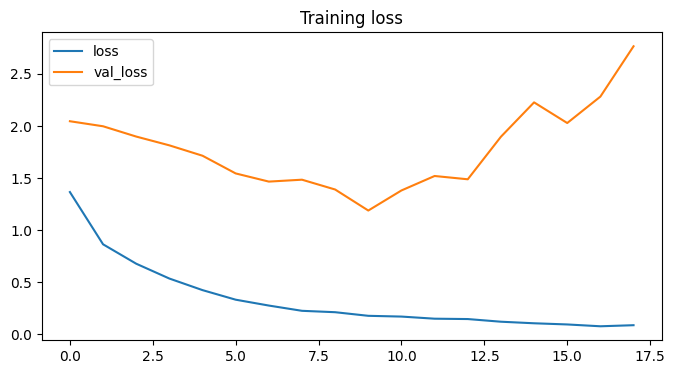

In [12]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(OUTPUT_ROOT / 'best_void_grid.keras', monitor='val_loss', save_best_only=True),
]
history = void_model.fit(fit_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)
pd.DataFrame(history.history)[['loss', 'val_loss']].plot(title='Training loss', figsize=(8, 4))
plt.show()
void_model.save(OUTPUT_ROOT / 'shelf_void_grid.keras')

In [13]:
# Export full INT8 TensorFlow Lite. The webcam script expects this exact 10x10x5 grid output.
def representative_data():
    for batch, _ in fit_ds.take(100):
        for image in batch:
            yield [tf.expand_dims(image, 0)]

converter = tf.lite.TFLiteConverter.from_keras_model(void_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8
MODEL_PATH = OUTPUT_ROOT / 'shelf_void_grid_int8.tflite'
MODEL_PATH.write_bytes(converter.convert())
print('Download this Kaggle Output:', MODEL_PATH, f'({MODEL_PATH.stat().st_size / 1e6:.2f} MB)')

interpreter = tf.lite.Interpreter(model_path=str(MODEL_PATH)); interpreter.allocate_tensors()
print('Input:', interpreter.get_input_details())
print('Output:', interpreter.get_output_details())

INFO:tensorflow:Assets written to: /tmp/tmp8w9k616_/assets


INFO:tensorflow:Assets written to: /tmp/tmp8w9k616_/assets


Saved artifact at '/tmp/tmp8w9k616_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 320, 320, 3), dtype=tf.float32, name='shelf_rgb')
Output Type:
  TensorSpec(shape=(None, 10, 10, 5), dtype=tf.float32, name=None)
Captures:
  133835569570896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133835569573968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133835409909392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133835409908816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133835569574736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133835569571472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133835409911312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133835409910160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133835409909776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133835409911120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133835409

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1788606821.338858      58 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1788606821.338907      58 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1788606821.354049      58 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


Download this Kaggle Output: /kaggle/working/retail_shelf_void_tf/shelf_void_grid_int8.tflite (0.43 MB)
Input: [{'name': 'serving_default_shelf_rgb:0', 'index': 0, 'shape': array([  1, 320, 320,   3], dtype=int32), 'shape_signature': array([ -1, 320, 320,   3], dtype=int32), 'dtype': <class 'numpy.uint8'>, 'quantization': (0.003921568859368563, 0), 'quantization_parameters': {'scales': array([0.00392157], dtype=float32), 'zero_points': array([0], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output: [{'name': 'StatefulPartitionedCall_1:0', 'index': 39, 'shape': array([ 1, 10, 10,  5], dtype=int32), 'shape_signature': array([-1, 10, 10,  5], dtype=int32), 'dtype': <class 'numpy.uint8'>, 'quantization': (0.00390625, 0), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([0], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
